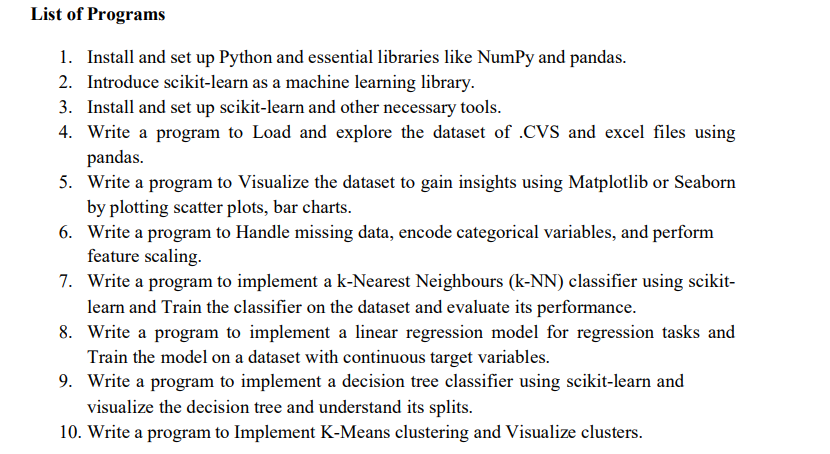

In [1]:
#Lab prg 1
import sys
print("Python version")
print(sys.version)

Python version
3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


In [2]:
!pip --version

pip 26.1.2 from C:\Users\ANISH NAZIRAN\AppData\Roaming\Python\Python314\site-packages\pip (python 3.14)



In [3]:
import pandas as pd
import numpy as np
print(np.__version__);
print(pd.__version__);

2.3.5
3.0.1


In [4]:
#Lab2
!pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
#Lab3

import sklearn
import numpy
import pandas
import matplotlib

print(sklearn.__version__)
print("scikit-learn installation path:", sklearn.__file__)
print(numpy.__version__)
print(pandas.__version__)
print(matplotlib.__version__)

1.9.0
scikit-learn installation path: C:\Users\ANISH NAZIRAN\AppData\Roaming\Python\Python314\site-packages\sklearn\__init__.py
2.3.5
3.0.1
3.10.8


In [7]:
#Lab4

import pandas as pd
def explore_csv(file_path):
    print("\nExploring CSV file:", file_path)
    
    data_csv = pd.read_csv(file_path)
    
    print("\nFirst 5 rows:\n", data_csv.head())
    print("\nData types:\n", data_csv.dtypes)
    print("\nShape of the dataset:\n", data_csv.shape)
    print("\nColumns of the dataset:\n", data_csv.columns)
    print("\nSummary of statistics:\n", data_csv.describe())
    print("\nDataFrame Info:")
    data_csv.info()

def explore_excel(file_path):
    print("\nExploring Excel file:", file_path)
    
    data_excel = pd.read_excel(file_path)
    
    print("\nFirst 5 rows:\n", data_excel.head())
    print("\nData types:\n", data_excel.dtypes)
    print("\nShape of the dataset:\n", data_excel.shape)
    print("\nColumns of the dataset:\n", data_excel.columns)
    print("\nSummary of statistics:\n", data_excel.describe())
    print("\nDataFrame Info:")
    data_excel.info()


# Function calls
explore_csv('Iris.csv')
explore_excel('Iris.xlsx')


C:\Users\ANISH NAZIRAN\Downloads


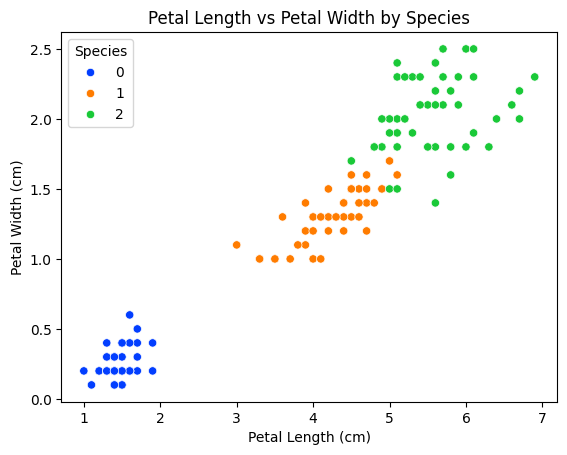

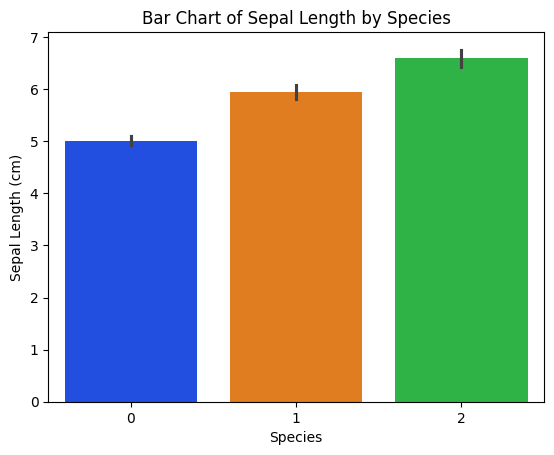

In [8]:
#Lab5

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset
iris_data = load_iris()


iris = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)


iris['species'] = iris_data.target



sns.scatterplot(
    data=iris,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    palette='bright'
)
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.show()


sns.barplot(
    data=iris,
    x='species',
    y='sepal length (cm)',
    hue='species',
    palette='bright',
    legend=False
)
plt.title('Bar Chart of Sepal Length by Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.show()

In [ ]:
#Lab6

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

data = {
    'Age': [25, 30, np.nan, 35, 40, 22, 50, np.nan, 28, 33],
    'Salary': [50000, 60000, 70000, np.nan, 90000, 40000, np.nan, 85000, 65000, 72000],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Male', 'Female', 'Female', 'Male'],
    'Purchased': ['Yes', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'No']
}

df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)

imputer_num = SimpleImputer(strategy='mean')
df[['Age', 'Salary']] = imputer_num.fit_transform(df[['Age', 'Salary']])

le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_purchased = LabelEncoder()
df['Purchased'] = le_purchased.fit_transform(df['Purchased'])

X = df.drop(columns=['Purchased'])
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train[['Age', 'Salary']] = scaler.fit_transform(X_train[['Age', 'Salary']])
X_test[['Age', 'Salary']] = scaler.transform(X_test[['Age', 'Salary']])

print("\nPreprocessed Training Data:")
print(X_train.reset_index(drop=True))

print("\nTransformed Target Variable:")
print(y_train)

Original DataFrame:
    Age   Salary  Gender Purchased
0  25.0  50000.0    Male       Yes
1  30.0  60000.0  Female        No
2   NaN  70000.0  Female       Yes
3  35.0      NaN    Male        No
4  40.0  90000.0  Female        No
5  22.0  40000.0    Male        No
6  50.0      NaN    Male       Yes
7   NaN  85000.0  Female        No
8  28.0  65000.0  Female       Yes
9  33.0  72000.0    Male        No

Preprocessed Training Data:
        Age    Salary  Gender
0 -1.467153 -1.782794       1
1 -1.095526 -1.134505       1
2 -0.120005  1.134505       0
3 -0.120005  0.162072       0
4 -0.104520  0.291730       1
5  0.762610  1.458650       0
6  0.143231 -0.064829       1
7  2.001367 -0.064829       1

Transformed Target Variable:
5    0
0    1
7    0
2    1
9    0
4    0
3    0
6    1
Name: Purchased, dtype: int64


In [ ]:
# LAB - 7
# Implement K-Nearest Neighbors (K-NN) classifier using scikit-learn
# Train on Iris dataset and evaluate performance

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
k = 3

knn_classifier = KNeighborsClassifier(n_neighbors=k)

knn_classifier.fit(X_train, y_train)

y_pred = knn_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix for KNN on Iris Dataset:")
print(cm)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix for KNN on Iris Dataset:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
# LAB - 8
# Build a Linear Regression model for regression tasks

import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([
    [1500, 3],
    [1200, 2],
    [1800, 4],
    [1000, 1],
    [1400, 3]
])
y = np.array([200, 150, 220, 130, 190])

model = LinearRegression()
model.fit(X, y)

new_size = float(input("Enter the size of the house: "))
new_bedroom = float(input("Enter the number of bedrooms: "))

predicted_price = model.predict([[new_size, new_bedroom]])

print("Predicted Price:", predicted_price[0])
print(f"Predicted price for a house with size {new_size} sq.ft and {new_bedroom} bedrooms is: {predicted_price[0]}")

Enter the size of the house:  40000
Enter the number of bedrooms:  4


Predicted Price: 1418.1249999999977
Predicted price for a house with size 40000.0 sq.ft and 4.0 bedrooms is: 1418.1249999999977


Accuracy: 1.0


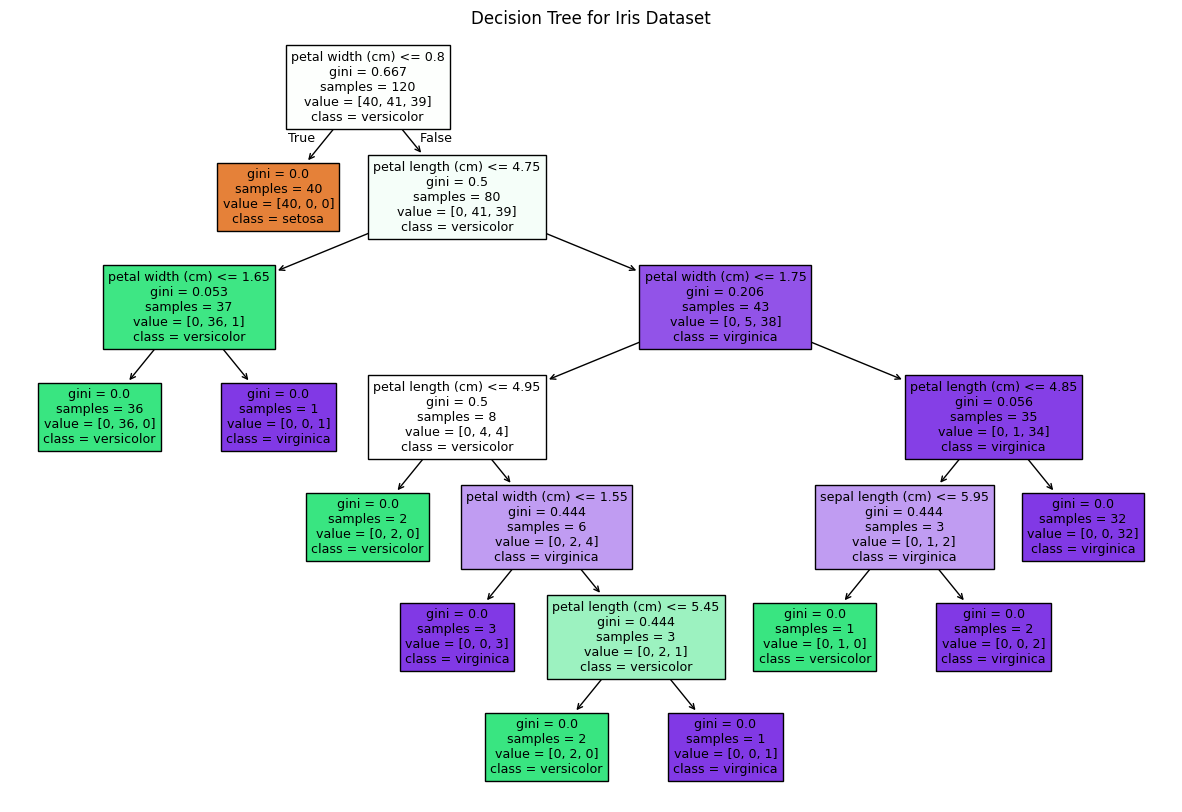

In [ ]:
# LAB - 9
# Implement Decision Tree Classifier and visualize it

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

decision_tree = DecisionTreeClassifier()

decision_tree.fit(X_train, y_train)

y_pred = decision_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

plt.figure(figsize=(15, 10))
plot_tree(
    decision_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Decision Tree for Iris Dataset")
plt.show()

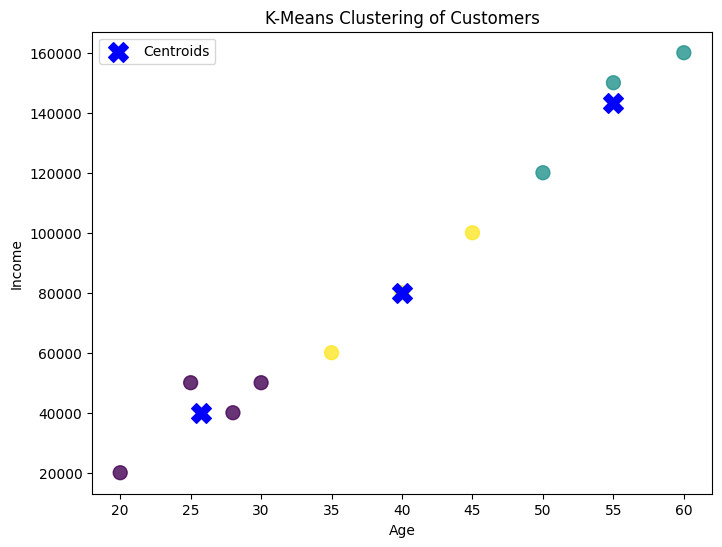

In [ ]:
# LAB - 10
# Implement K-Means clustering and visualize clusters

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings("ignore")

X = np.array([
    [30, 50000],
    [35, 60000],
    [40, 80000],
    [25, 50000],
    [45, 100000],
    [20, 20000],
    [50, 120000],
    [55, 150000],
    [60, 160000],
    [28, 40000]
])

kmeans = KMeans(n_clusters=3, random_state=0)

kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=labels, s=100, alpha=0.8)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='blue',
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("K-Means Clustering of Customers")
plt.legend()

plt.show()